# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [1]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.0 MB/s eta 0:00:00


In [2]:
# Data wrangling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Pre-processing & metrics
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
)

# Neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam

# Misc
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Display settings
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [2]:
# Connect to Google Drive to read and load the data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the train and test datasets
train_df = pd.read_csv('/content/drive/MyDrive/notebooks_data/INN_Renewind_Project/Train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/notebooks_data/INN_Renewind_Project/Test.csv')

# Keep copy of the original data
data = train_df.copy()
data_test = test_df.copy()

print("Train shape :", data.shape)
print("Test shape  :", data_test.shape)

Train shape : (20000, 41)
Test shape  : (5000, 41)


# **Data Overview**

In [5]:
# First five rows
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,-5.714719,0.735893,0.981251,1.417884,-3.375815,-3.047303,0.306194,2.914097,2.269979,4.394876,-2.388299,0.646388,-1.190508,3.132986,0.665277,-2.510846,-0.036744,0.726218,-3.982187,-1.072638,1.667098,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,1.914465,-0.951458,-1.255259,-2.706522,0.193223,-4.769379,-2.205319,0.907716,0.756894,-5.833678,-3.065122,1.596647,-1.757311,1.766444,-0.267098,3.625036,1.500346,-0.585712,0.783034,-0.201217,0.024883,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,-0.770673,1.106718,1.144261,0.943301,-3.163804,-4.247825,-4.038909,3.688534,3.311196,1.059002,-2.143026,1.650120,-1.660592,1.679910,-0.450782,-4.550695,3.738779,1.134404,-2.033531,0.840839,-1.600395,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,-3.053023,0.459719,2.704527,-0.636086,-0.453717,-3.174046,-3.404347,-1.281536,1.582104,-1.951778,-3.516555,-1.206011,-5.627854,-1.817653,2.124142,5.294642,4.748137,-2.308536,-3.962977,-6.028730,4.948770,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,1.998347,4.723757,0.709113,-1.989432,-2.632684,4.184447,2.245356,3.734452,-6.312766,-5.379918,-0.886667,2.061694,9.445586,4.489976,-3.945144,4.582065,-8.780422,-3.382967,5.106507,6.787513,2.044184,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [6]:
# Last five rows
data.tail()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19995,-2.071318,-1.088279,-0.796174,-3.011720,-2.287540,2.807310,0.481428,0.105171,-0.586599,-2.899398,8.868415,1.717155,1.357838,-1.777135,0.709780,4.944939,-3.100454,-1.199228,-1.084629,-0.365044,3.131175,-3.948103,-3.578469,-8.139067,-1.936861,-1.327691,-0.402688,-1.734796,9.996461,6.955367,-3.938493,-8.273996,5.745013,0.589014,-0.649988,-3.043174,2.216461,0.608723,0.178193,2.927755,1
19996,2.890264,2.483069,5.643919,0.937053,-1.380870,0.412051,-1.593386,-5.762498,2.150096,0.272302,-2.094760,-1.525834,0.071573,-3.540142,-2.762006,-10.632206,-0.495236,1.720074,3.871596,-1.209610,-8.222073,2.120866,-5.491808,1.452340,1.450002,3.684654,1.076760,-0.384175,-0.838593,-0.748275,-1.088553,-4.159092,1.181466,-0.742412,5.368979,-0.693028,-1.668971,3.659954,0.819863,-1.987265,0
19997,-3.896979,-3.942407,-0.351364,-2.417462,1.107546,-1.527623,-3.519882,2.054792,-0.233996,-0.357687,-3.781972,2.180042,6.111780,1.984747,-8.330002,-1.639184,-0.914960,5.672348,-3.924200,2.133196,-4.502031,2.777178,5.727949,1.619818,-1.699691,-0.041882,-2.923094,-2.760158,-2.253766,2.552033,0.981858,7.112162,1.476080,-3.953710,1.855555,5.029209,2.082588,-6.409304,1.477138,-0.874148,0
19998,-3.187322,-10.051662,5.695955,-4.370053,-5.354758,-1.873044,-3.947210,0.679420,-2.389254,5.456756,1.583029,3.571478,9.226573,2.553587,-7.039109,-0.993573,-9.664938,1.155224,3.876895,3.523634,-7.015329,-0.132037,-3.446179,-4.801443,-0.875727,-3.811854,5.422077,-3.732322,0.608811,5.256460,1.914766,0.402812,3.163661,3.752095,8.529894,8.450626,0.203958,-7.129918,4.249394,-6.112267,0
19999,-2.686903,1.961187,6.137088,2.600133,2.657241,-4.290882,-2.344267,0.974004,-1.027462,0.497421,-9.589075,3.176560,1.054517,-1.415882,-4.668611,-5.405377,3.719759,2.892923,2.328591,1.457704,-6.428543,1.818232,0.805897,7.786026,0.330857,5.257424,-4.867417,-0.818941,-5.667393,-2.860975,4.674280,6.620811,-1.988786,-1.348901,3.951801,5.449706,-0.455411,-2.202056,1.678229,-1.974413,0


In [7]:
# Dataset structure
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

Observations:

*   The training set has 20,000 rows and 41 columns (40 predictors V1–V40 and the binary Target).
*   All 40 predictors are float64 and the target is int64.
*   There are some missing values in columns V1 and V2 that we will need to treat.

In [8]:
# Statistical summary of predictors
data.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


**Observations:**
- The features seem to be **transformed** — they include negative values and span similar ranges.
- The means are close to zero for many features and standard deviations are roughly in the same order of magnitude, which is consistent with a centered transformation.

In [9]:
# Missing values
missing = data.isnull().sum()
missing[missing > 0]

,0
V1,18
V2,18


In [10]:
# Missing values in test set
missing_test = data_test.isnull().sum()
missing_test[missing_test > 0]

,0
V1,5
V2,6


**Observations:**
- Only `V1` and `V2` have missing values:
  - Train: 18 missing in `V1`, 18 in `V2`.
  - Test:  5 missing in `V1`, 6 in `V2`.
- The proportion of missing values is very small (< 0.1%), so we can safely impute with the mean **fit on the training set only** to avoid data leakage.

In [11]:
# Duplicate rows
print("Duplicate rows in train:", data.duplicated().sum())
print("Duplicate rows in test :", data_test.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test : 0


In [12]:
# Target distribution
target_counts = data['Target'].value_counts()
target_pct   = data['Target'].value_counts(normalize=True) * 100
target_summary = pd.concat([target_counts, target_pct.round(2)], axis=1)
target_summary.columns = ['Count', 'Percentage']
target_summary

,Count,Percentage
Target,,
0,18890,94.45
1,1110,5.55


**Observations:**
- The classes are highly **imbalanced**: only about **5.6%** of observations correspond to a failure (`Target = 1`).
- This imbalance is Significant:
  - We may need to pick an evaluation metric that focuses on the minority (failure) class — **Recall**.
  - **Class weights** may need to be used during training so the model does not just predict "no failure" everywhere.

# **Exploratory Data Analysis**

## Univariate analysis

### Target Variable Distribution

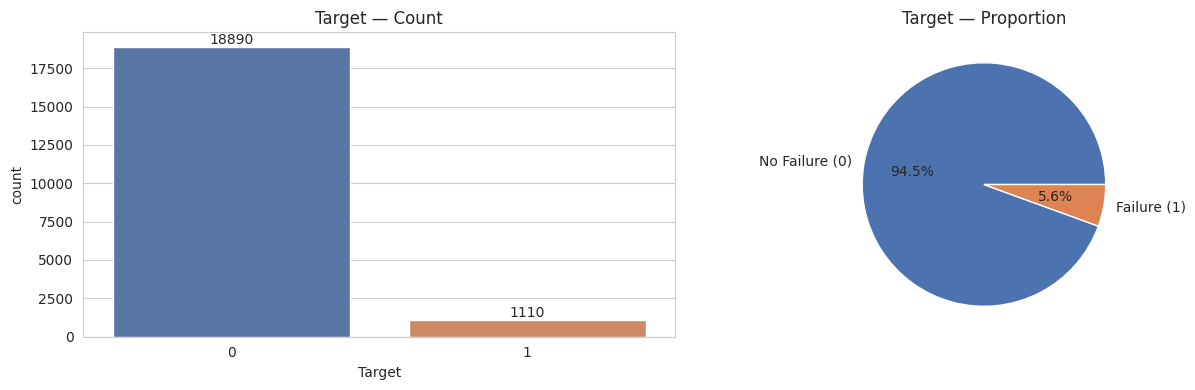

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x='Target', data=data, ax=ax[0], palette=['#4C72B0', '#DD8452'])
ax[0].set_title("Target — Count")
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height())}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom')

data['Target'].value_counts().plot.pie(
    autopct='%1.1f%%', ax=ax[1], colors=['#4C72B0', '#DD8452'],
    labels=['No Failure (0)', 'Failure (1)']
)
ax[1].set_ylabel("")
ax[1].set_title("Target — Proportion")
plt.tight_layout()
plt.show()

**Insight:** Only ~5.6% of observations are failures — the data is heavily skewed toward the *no-failure* class.

### Distribution of the Predictors

Since there are 40 numeric predictors, will plot them as a grid of histograms and box-plots to identify spread and outliers.

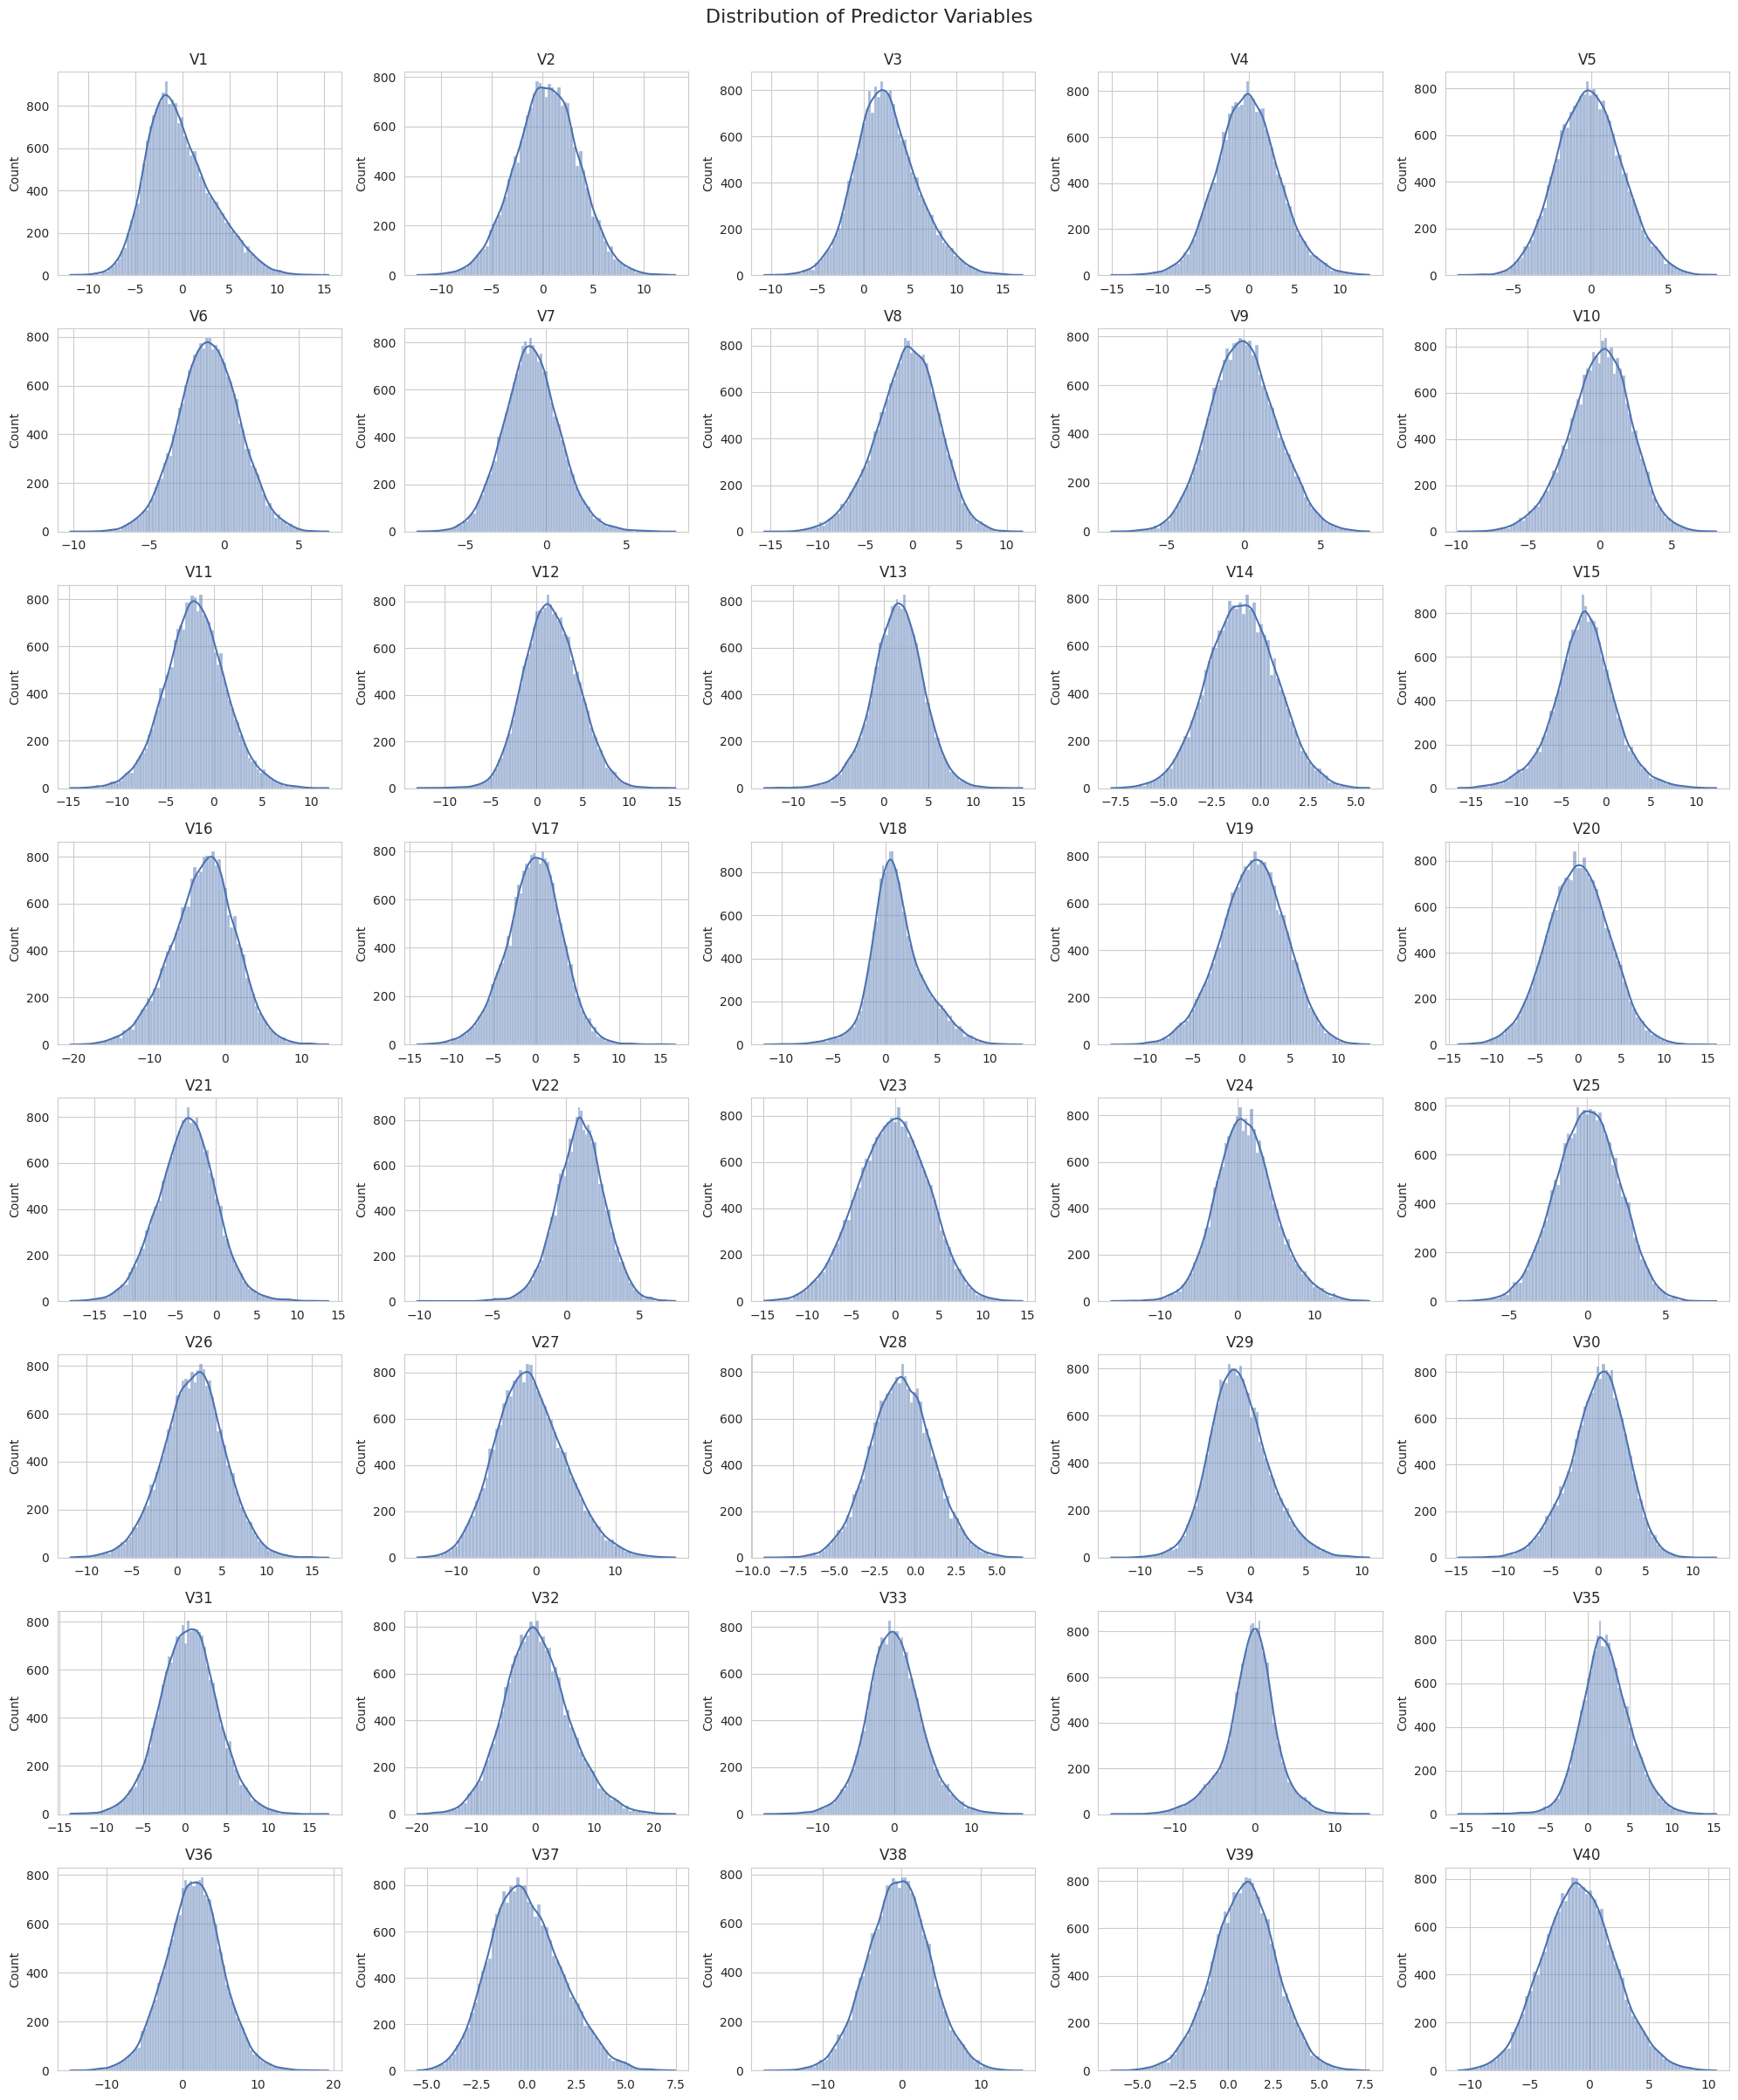

In [14]:
# Histograms for every predictor
features = [c for c in data.columns if c != 'Target']

fig, axes = plt.subplots(8, 5, figsize=(20, 24))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.histplot(data[col].dropna(), kde=True, ax=axes[i],
                 color='#4C72B0', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel("")
plt.suptitle("Distribution of Predictor Variables", y=1.00, fontsize=16)
plt.tight_layout()
plt.show()

**Observations:**
- Most of the predictors look **approximately symmetric / bell-shaped** — consistent with a standardised transformation.
- A few features show mild skew, and many appear to have moderate to long tails.
- Since the data has already been transformed, we cannot attribute physical meaning to individual variables.

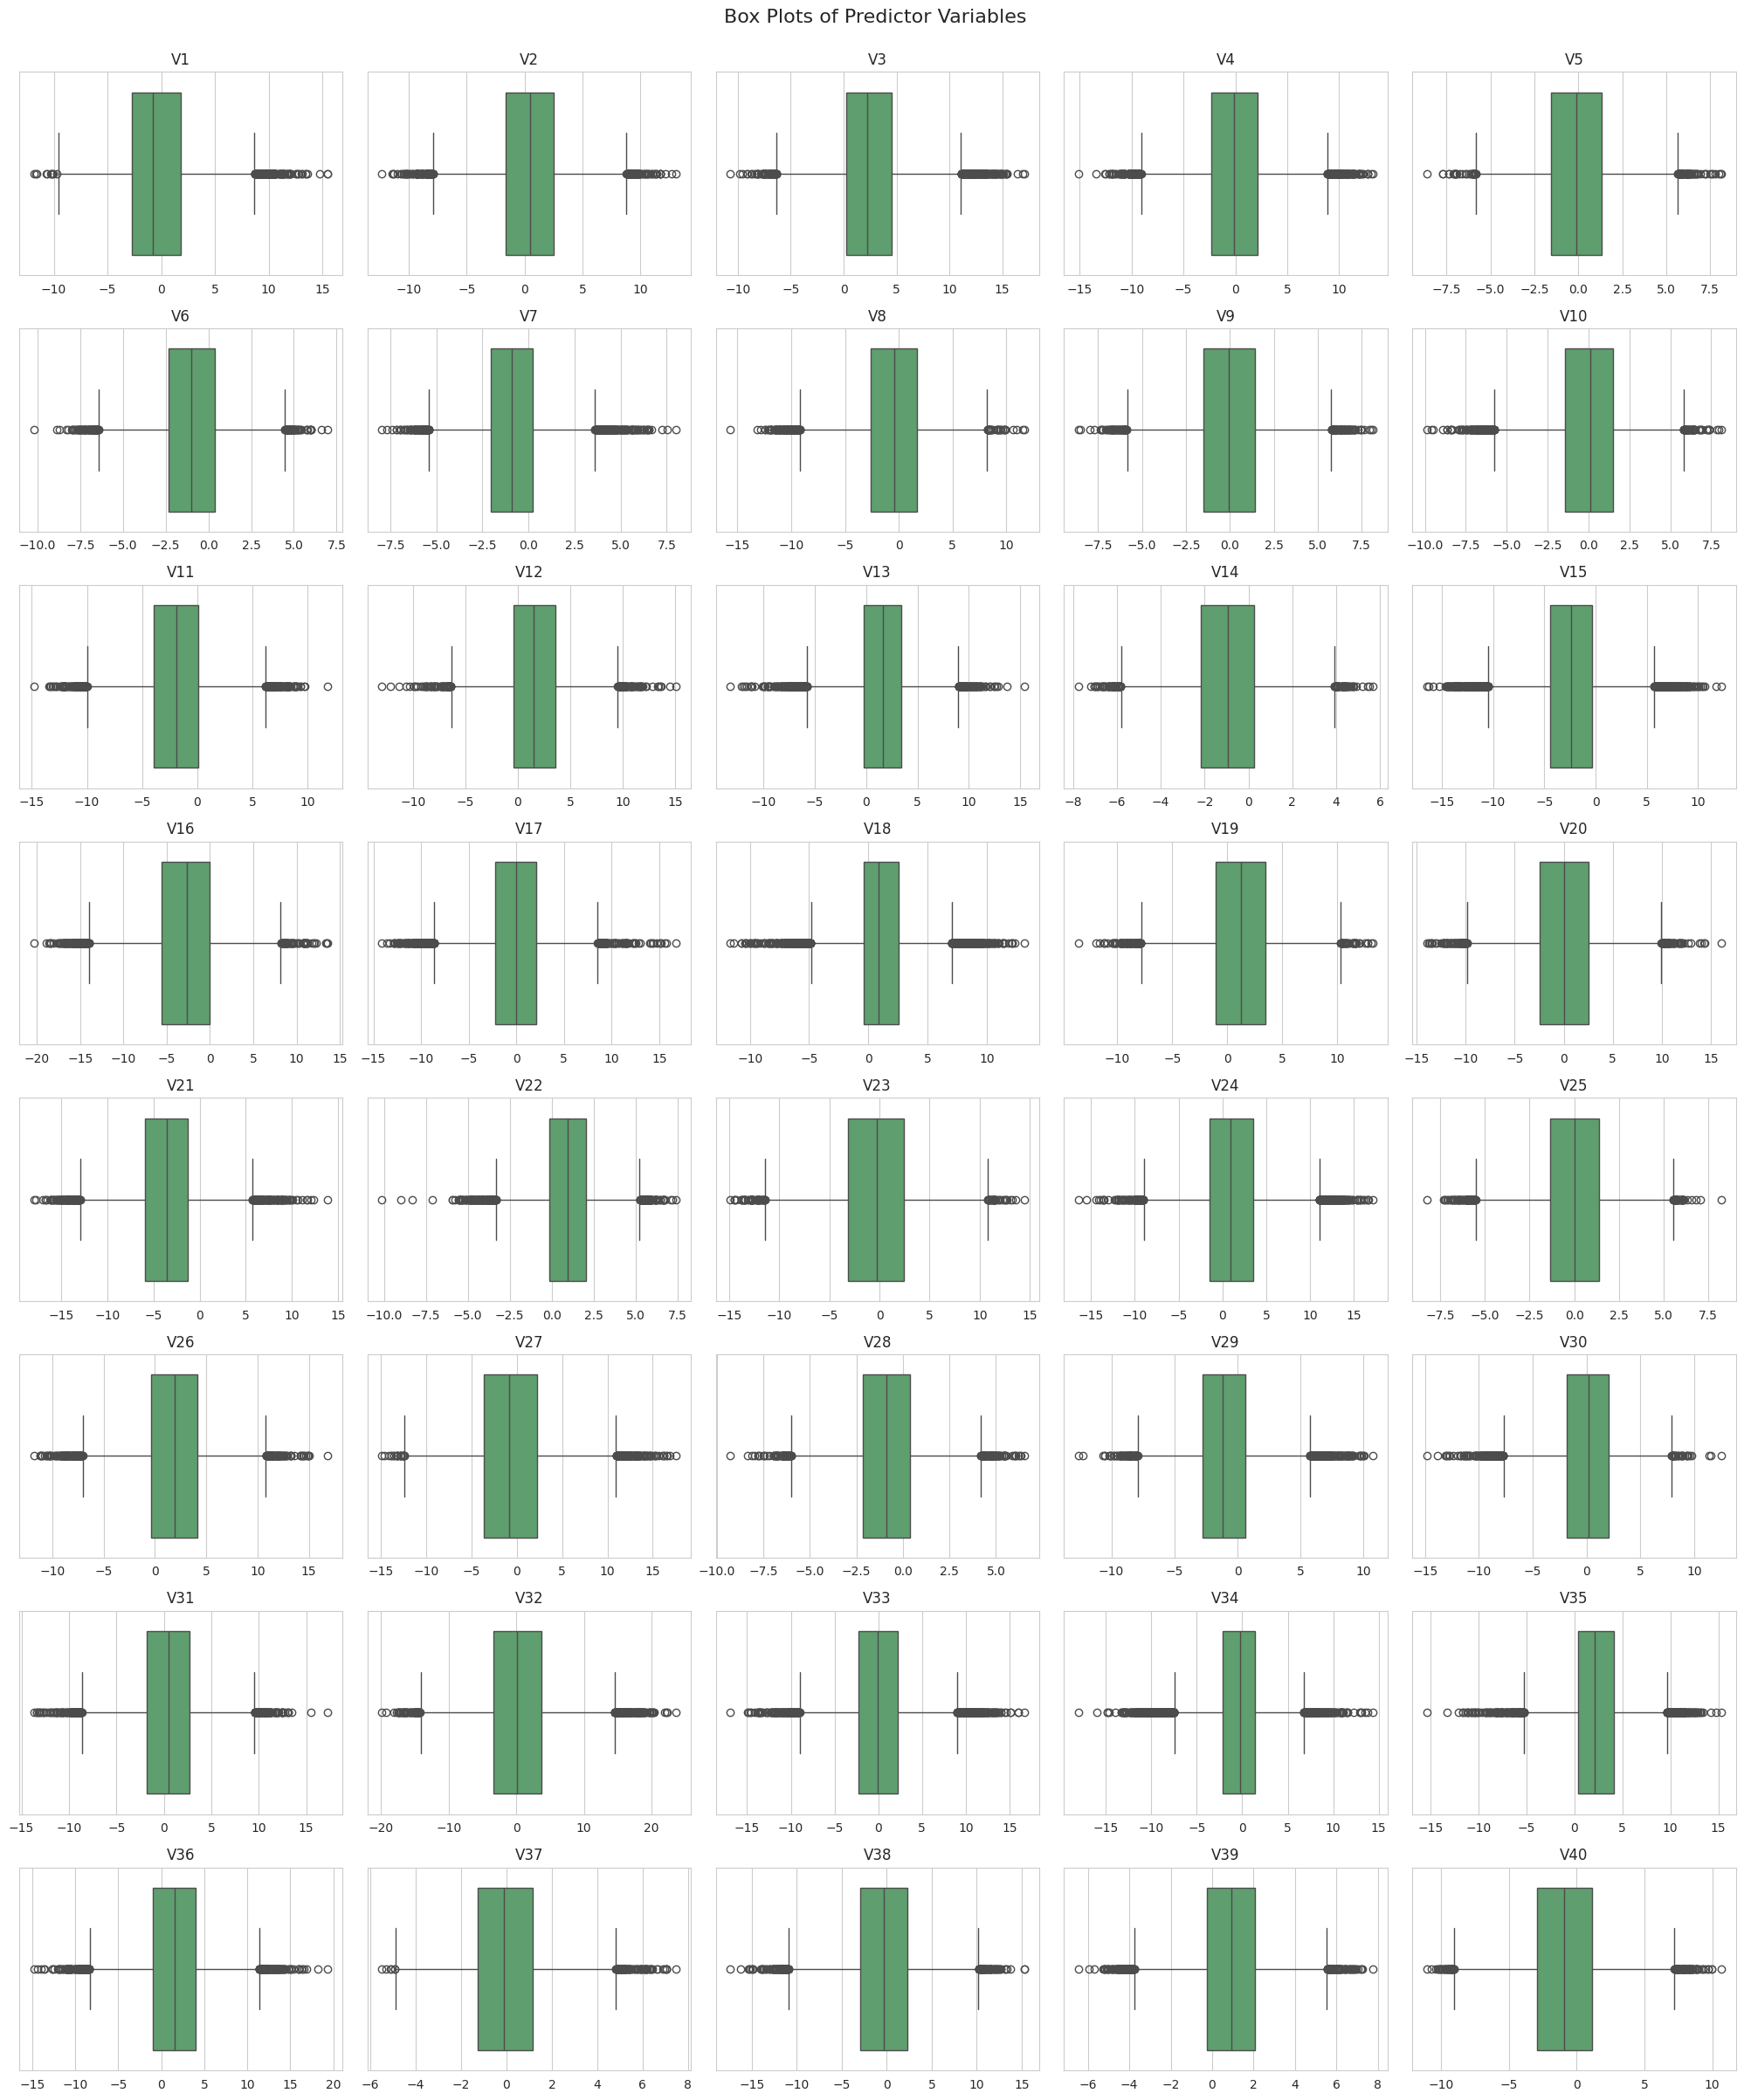

In [15]:
# Box plots for every predictor to inspect outliers
fig, axes = plt.subplots(8, 5, figsize=(20, 24))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(x=data[col], ax=axes[i], color='#55A868')
    axes[i].set_title(col)
    axes[i].set_xlabel("")
plt.suptitle("Box Plots of Predictor Variables", y=1.00, fontsize=16)
plt.tight_layout()
plt.show()

**Observations:**
- Outliers are present in essentially every feature, but they are not extreme in magnitude.
- Since the predictors are transformed measurements, **will not remove or cap** outliers — they may represent genuine failure-related sensor readings, and removing them could destroy signal.
- Standardizing (zero-mean, unit-variance) will be useful for building the neural network

## Bivariate Analysis

### Correlation Among Predictors

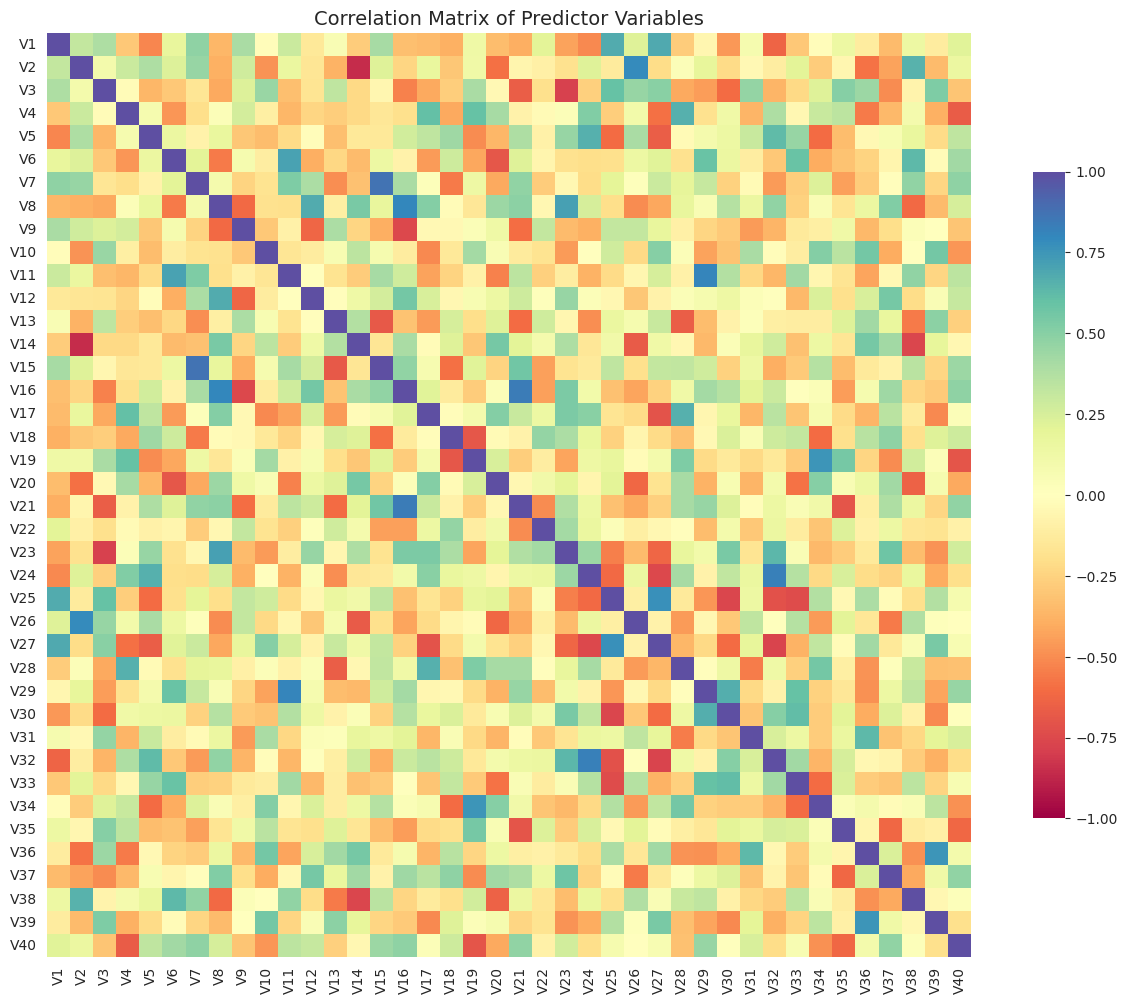

In [16]:
plt.figure(figsize=(16, 12))
corr = data[features].corr()
sns.heatmap(corr, cmap="Spectral", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": .7})
plt.title("Correlation Matrix of Predictor Variables", fontsize=14)
plt.show()

In [17]:
# Highly correlated pairs (|r| > 0.7) just to see if multicollinearity is severe
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
high_corr = (corr.where(mask)
             .stack()
             .reset_index()
             .rename(columns={'level_0': 'Feature_1',
                              'level_1': 'Feature_2',
                              0: 'Correlation'}))
high_corr = high_corr[high_corr['Correlation'].abs() > 0.7].sort_values('Correlation', key=abs, ascending=False)
high_corr.head(20)

,Feature_1,Feature_2,Correlation
226,V7,V15,0.867871
50,V2,V14,-0.853530
484,V16,V21,0.836527
651,V24,V32,0.825119
362,V11,V29,0.811228
259,V8,V16,0.802505
62,V2,V26,0.787440
96,V3,V23,-0.785580
661,V25,V27,0.766255
693,V27,V32,-0.765733


**Observations:**
- Most predictor pairs show **weak correlations** — there is no widespread multicollinearity.
- A handful of pairs show stronger correlation (|r| > 0.7), but since we are using neural networks (which can handle correlated inputs well after standardization), this is not a blocking issue.

### Distribution of Predictors by Target Class

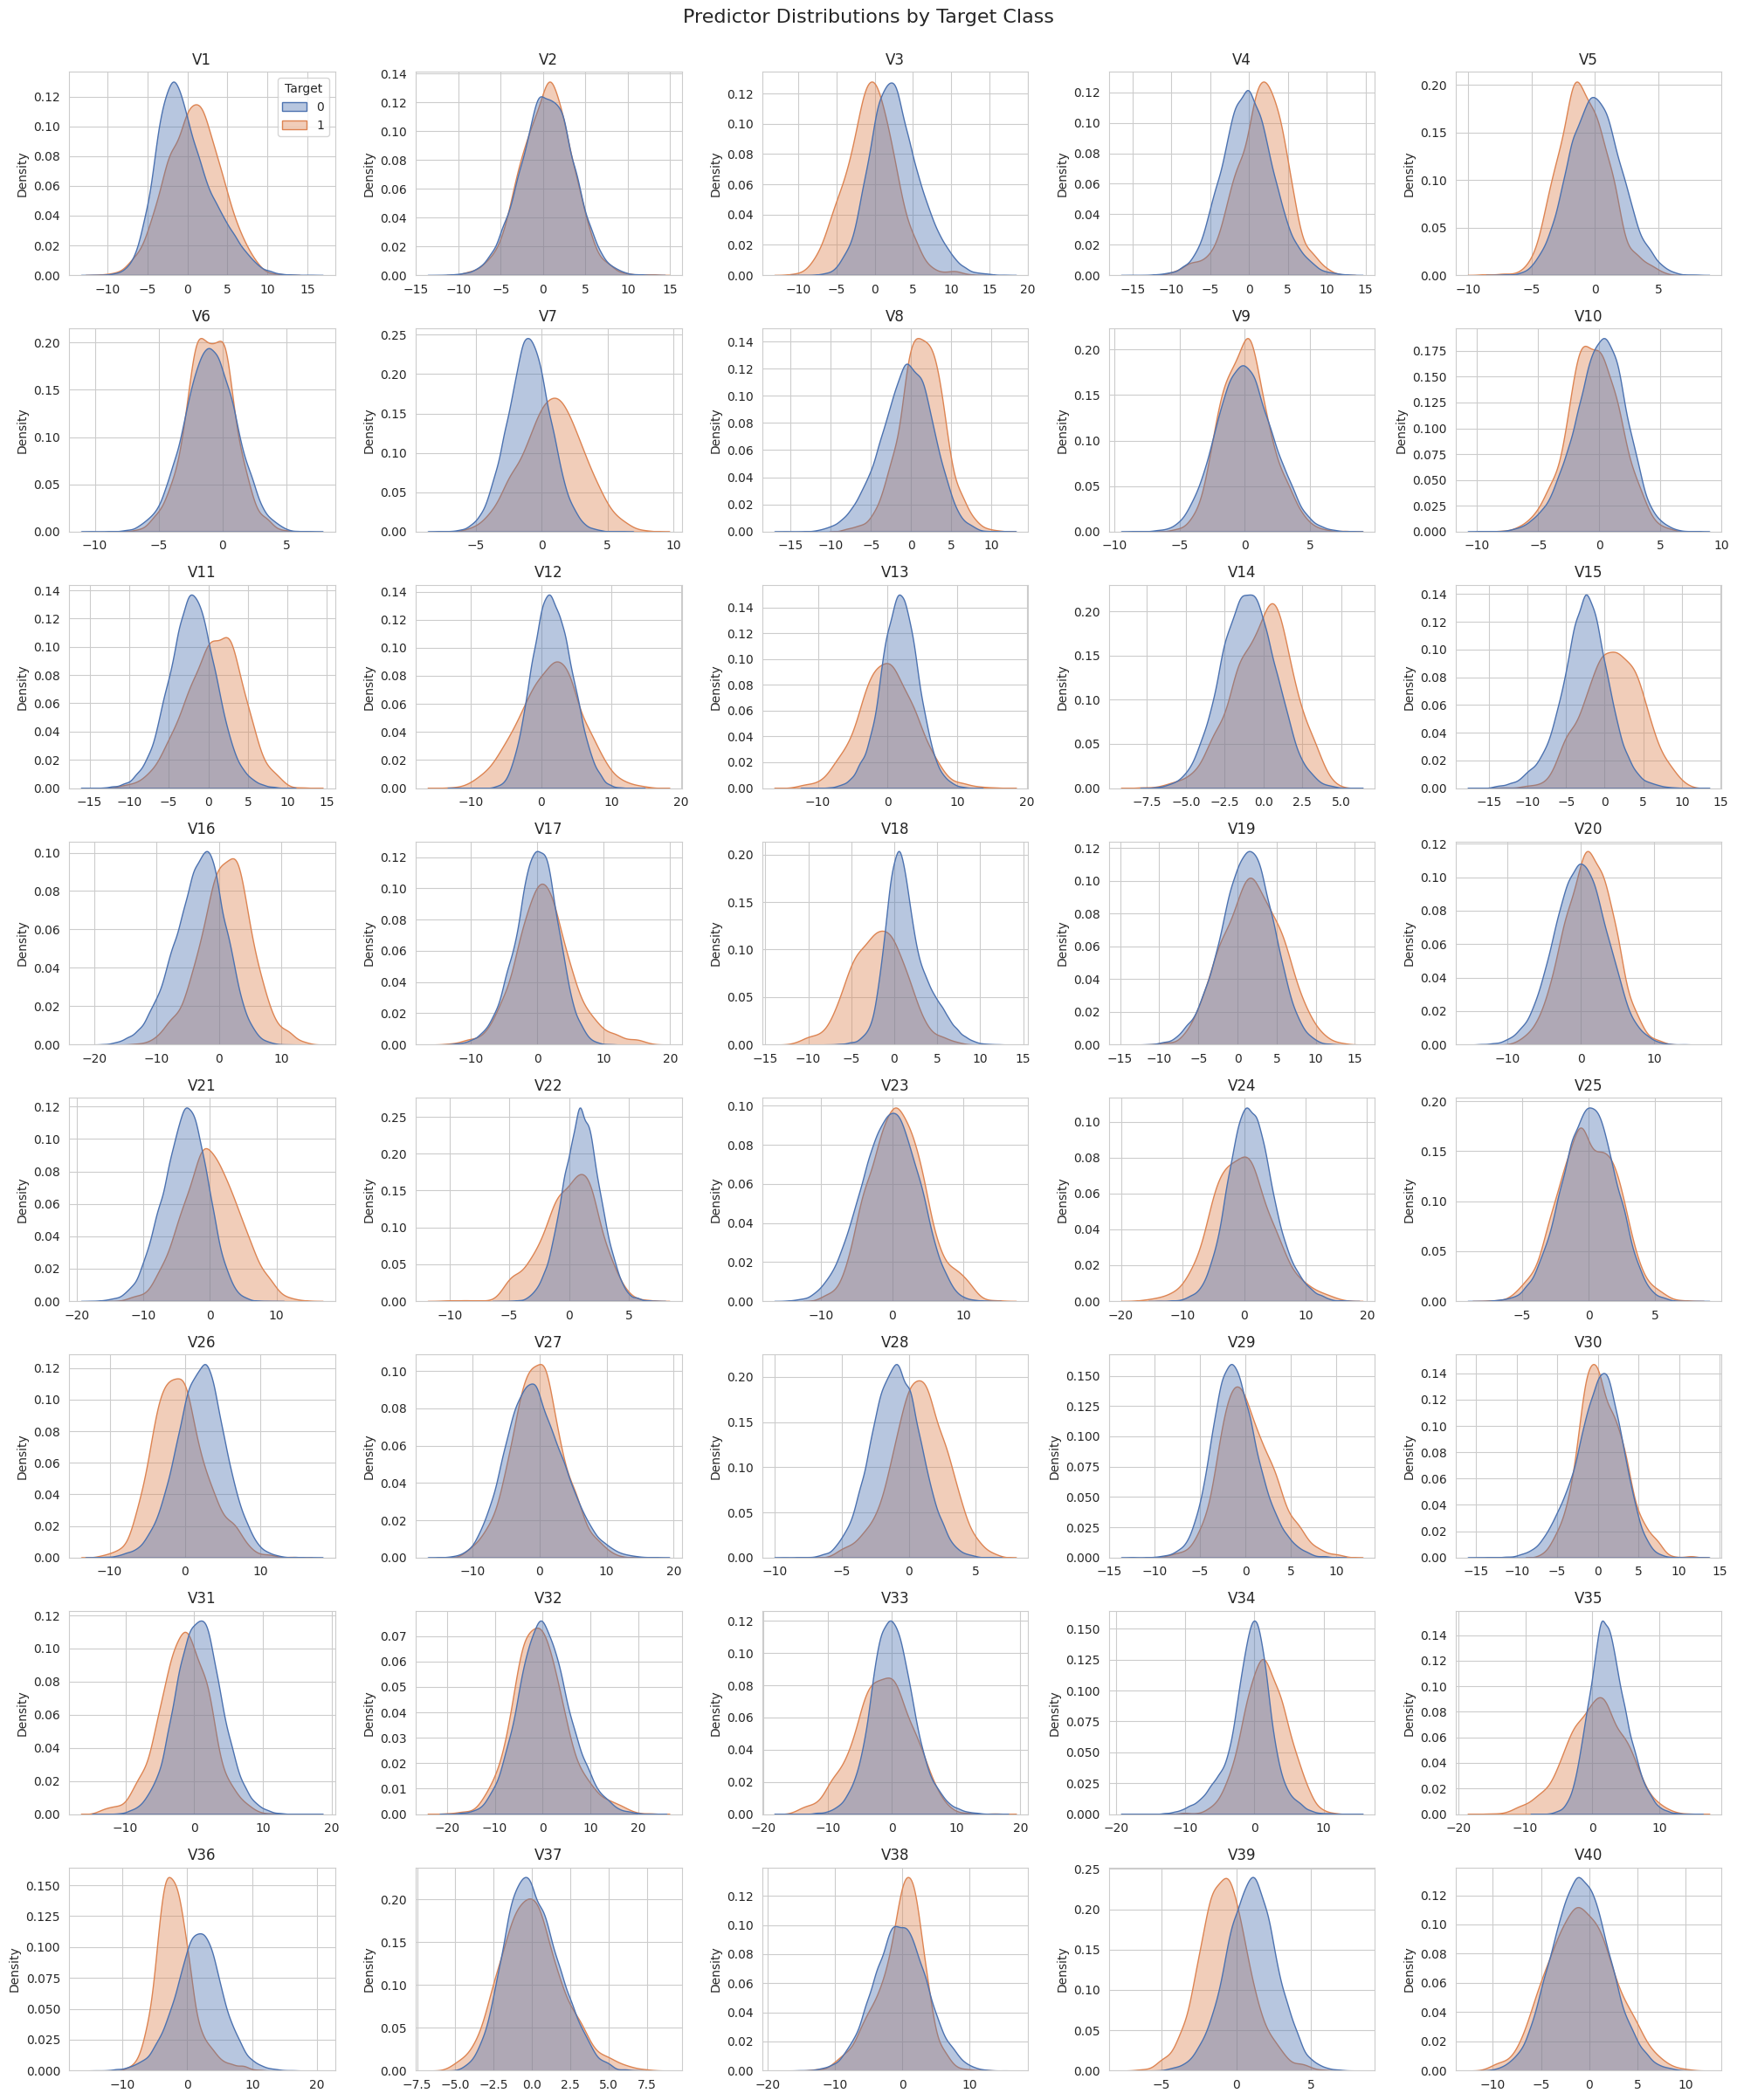

In [18]:
# How do the feature distributions differ for failures vs no-failures?
fig, axes = plt.subplots(8, 5, figsize=(20, 24))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.kdeplot(data=data, x=col, hue='Target',
                ax=axes[i], common_norm=False,
                palette={0: '#4C72B0', 1: '#DD8452'}, fill=True, alpha=0.4)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    if i != 0 and axes[i].get_legend() is not None:
        axes[i].get_legend().remove()
plt.suptitle("Predictor Distributions by Target Class", y=1.00, fontsize=16)
plt.tight_layout()
plt.show()

**Observations:**
- For several predictors, the *failure* and *no-failure* distributions clearly diverge — this suggests these features carry **predictive signal**.
- For others, the two distributions overlap heavily — those features will contribute less individually, but combinations of them may still help.

In [19]:
# Mean of each predictor by target class
mean_by_target = data.groupby('Target')[features].mean().T
mean_by_target['abs_diff'] = (mean_by_target[1] - mean_by_target[0]).abs()
mean_by_target = mean_by_target.sort_values('abs_diff', ascending=False)
mean_by_target.head(15)

Target,0,1,abs_diff
V16,-3.161114,1.089148,4.250262
V21,-3.832999,0.162445,3.995444
V15,-2.617588,1.032767,3.650355
V36,1.714234,-1.879015,3.593249
V18,1.373673,-1.947521,3.321194
V3,2.660379,-0.505019,3.165397
V26,2.024059,-0.683572,2.707631
V11,-2.044374,0.639956,2.684329
V34,-0.581442,1.558006,2.139448
V31,0.601750,-1.468659,2.070409


**Insight:** The top predictors by mean separation between classes are candidates for being the most informative for the model. We will not drop any features — the neural network will learn which to weight.

# **Data Preprocessing**

1. **Separate** predictors (`X`) and the target (`y`) for both train and test sets.
2. **Split** the training set into training and validation subsets (stratified to preserve class balance).
3. **Impute** missing values using the **mean of the training subset only** — fit on train, transform on val/test (prevents data leakage).
4. **Standardize** the predictors using `StandardScaler` — again, fit on training, transform on val/test.

In [20]:
# 1) Split predictors and target
X = data.drop(columns=['Target'])
y = data['Target']

X_test = data_test.drop(columns=['Target'])
y_test = data_test['Target']

print("X       :", X.shape, "| y       :", y.shape)
print("X_test  :", X_test.shape, "| y_test  :", y_test.shape)

X       : (20000, 40) | y       : (20000,)
X_test  : (5000, 40) | y_test  : (5000,)


In [21]:
# 2) Train / Validation split — stratified to maintain class proportion
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print("Train :", X_train.shape, "| Val :", X_val.shape)
print()
print("Failure rate — train:", round(y_train.mean(), 4),
      "| val:", round(y_val.mean(), 4),
      "| test:", round(y_test.mean(), 4))

Train : (16000, 40) | Val : (4000, 40)

Failure rate — train: 0.0555 | val: 0.0555 | test: 0.0564


In [22]:
# 3) Impute missing values — fit on TRAIN only, then transform val and test
imputer = SimpleImputer(strategy='mean')

X_train = pd.DataFrame(imputer.fit_transform(X_train),
                       columns=X_train.columns, index=X_train.index)
X_val   = pd.DataFrame(imputer.transform(X_val),
                       columns=X_val.columns,   index=X_val.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test),
                          columns=X_test.columns, index=X_test.index)

print("Missing in train after impute:", X_train.isnull().sum().sum())
print("Missing in val   after impute:", X_val.isnull().sum().sum())
print("Missing in test  after impute:", X_test_imp.isnull().sum().sum())

Missing in train after impute: 0
Missing in val   after impute: 0
Missing in test  after impute: 0


In [23]:
# 4) Standardize — fit on TRAIN only, then transform val and test
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test_imp)

print("Train mean/std (should be ~0/1):",
      round(X_train_s.mean(), 4), round(X_train_s.std(), 4))
print("Val   mean/std:",
      round(X_val_s.mean(), 4), round(X_val_s.std(), 4))

Train mean/std (should be ~0/1): 0.0 1.0
Val   mean/std: 0.0017 0.9966


# **Model Building**

## Model Evaluation Criterion

### Why **Recall** is the right primary metric

Based on the cost structure described in the problem statement:

| Outcome | Meaning | Cost |
|---|---|---|
| **True Positive (TP)** | Predicted failure, actually a failure | **Repair** (medium) |
| **False Negative (FN)** | Predicted *no failure*, actually a failure | **Replacement** (highest) |
| **False Positive (FP)** | Predicted failure, actually no failure | **Inspection** (lowest) |
| **True Negative (TN)** | Predicted *no failure*, actually no failure | None |

**Cost ranking:** Replacement (FN) **>** Repair (TP) **>** Inspection (FP)

A **False Negative is the most expensive mistake** — a real failure goes undetected and the generator must be replaced. A **False Positive** is the cheapest mistake — an unnecessary inspection.

Therefore, we want to **minimize False Negatives**, which is equivalent to **maximizing Recall** on the failure class:

$$\text{Recall} = \frac{TP}{TP + FN}$$

We will also report **Precision**, **F1-score** and **Accuracy** as secondary metrics. The classes are imbalanced (~5.6% failures), so plain accuracy is misleading — a model that predicts "no failure" for everything would achieve high accuracy and **low recall**, which is exactly the kind of model we want to avoid.

In [24]:
# Helper functions for evaluation and plotting
def evaluate_model(model, X_tr, y_tr, X_v, y_v, threshold=0.5, name=""):
    """Return a one-row DataFrame with train/val performance for a Keras model."""
    y_tr_pred = (model.predict(X_tr, verbose=0) > threshold).astype(int).ravel()
    y_v_pred  = (model.predict(X_v,  verbose=0) > threshold).astype(int).ravel()

    row = {
        'Model': name,
        'Train Accuracy':  accuracy_score(y_tr,  y_tr_pred),
        'Train Precision': precision_score(y_tr, y_tr_pred, zero_division=0),
        'Train Recall':    recall_score(y_tr,    y_tr_pred, zero_division=0),
        'Train F1':        f1_score(y_tr,        y_tr_pred, zero_division=0),
        'Val Accuracy':    accuracy_score(y_v,   y_v_pred),
        'Val Precision':   precision_score(y_v,  y_v_pred, zero_division=0),
        'Val Recall':      recall_score(y_v,     y_v_pred, zero_division=0),
        'Val F1':          f1_score(y_v,         y_v_pred, zero_division=0),
    }
    return pd.DataFrame([row])

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Failure', 'Failure'],
                yticklabels=['No Failure', 'Failure'], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'], label='Train')
    if 'val_loss' in history.history:
        axes[0].plot(history.history['val_loss'], label='Validation')
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    metric = 'recall' if 'recall' in history.history else 'accuracy'
    axes[1].plot(history.history[metric], label='Train')
    val_metric = f"val_{metric}"
    if val_metric in history.history:
        axes[1].plot(history.history[val_metric], label='Validation')
    axes[1].set_title(f"{title} — {metric.capitalize()}")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel(metric.capitalize()); axes[1].legend()

    plt.tight_layout()
    plt.show()

## Initial Model Building (Model 0)

We start with a simple baseline neural network:

- **One hidden layer** with 32 units
- **ReLU** activation
- **SGD** optimizer
- **Sigmoid** output (binary classification)
- **Binary crossentropy** loss

In [25]:
def build_model_0():
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    model = Sequential([
        Input(shape=(X_train_s.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=SGD(learning_rate=0.01),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
    return model

model_0 = build_model_0()
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

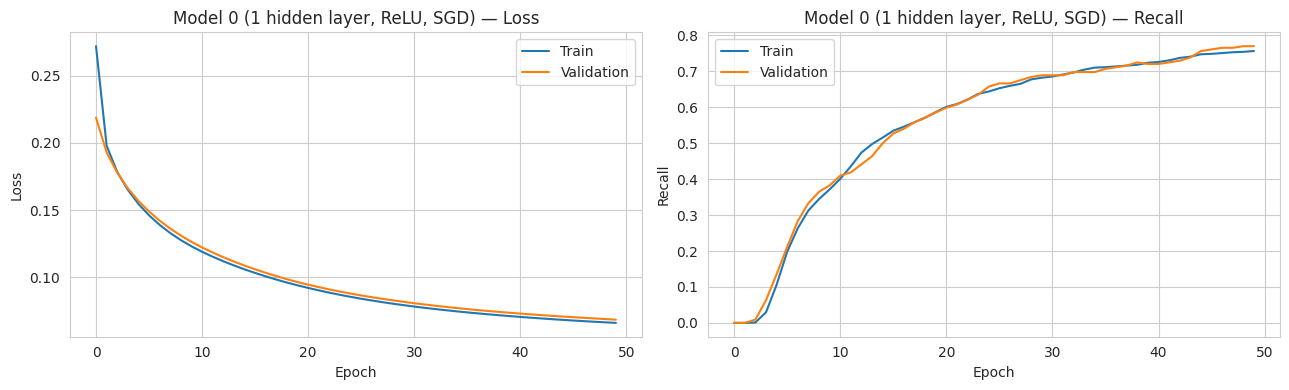

In [26]:
history_0 = model_0.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=50, batch_size=64, verbose=0
)
plot_history(history_0, title="Model 0 (1 hidden layer, ReLU, SGD)")

In [27]:
results = evaluate_model(model_0, X_train_s, y_train, X_val_s, y_val, name="Model 0 — 1HL, SGD")
results

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Val Accuracy,Val Precision,Val Recall,Val F1
0,"Model 0 — 1HL, SGD",0.986062,0.985401,0.760135,0.858233,0.98675,0.988439,0.77027,0.865823


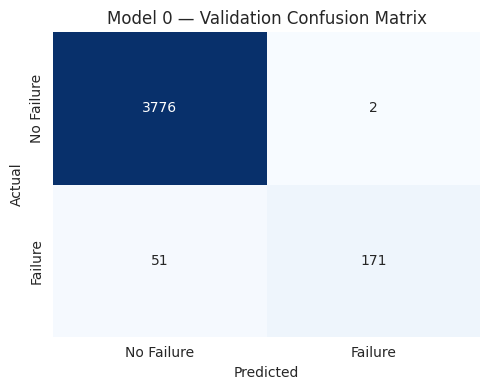

              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      3778
     Failure       0.99      0.77      0.87       222

    accuracy                           0.99      4000
   macro avg       0.99      0.88      0.93      4000
weighted avg       0.99      0.99      0.99      4000



In [28]:
y_val_pred_0 = (model_0.predict(X_val_s, verbose=0) > 0.5).astype(int).ravel()
plot_confusion(y_val, y_val_pred_0, title="Model 0 — Validation Confusion Matrix")
print(classification_report(y_val, y_val_pred_0, target_names=['No Failure', 'Failure']))

### Model 0 — Observations

- The baseline model has decent overall accuracy but **recall on the failure class is poor** — it misses too many failures.
- This is exactly the issue we expected: with a heavily imbalanced dataset, a vanilla model just learns to predict the majority class.
- We need to improve recall — the strategies we will try are:
  1. Deeper architectures (more hidden layers / units)
  2. **Batch Normalization** to stabilize and accelerate training
  3. A more powerful optimizer (**Adam**) for faster, more stable convergence
  4. **Dropout** to prevent overfitting in deeper networks
  5. **Class weights** to penalize misclassifying failures more heavily — directly attacks the imbalance
  6. Combinations of the above

# **Model Performance Improvement**

We will try to improve performance by building **6 improved models** which will be combining:

Deeper architectures, **Batch Normalization** after each hidden layer, different optimizers (SGD vs Adam), dropout, and class weights.



In [29]:
# Compute class weights inversely proportional to class frequency.
from sklearn.utils.class_weight import compute_class_weight
classes  = np.unique(y_train)
weights  = compute_class_weight(class_weight='balanced',
                                classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights (failure class gets a much higher weight):", class_weights)

Class weights (failure class gets a much higher weight): {0: 0.5293806246691372, 1: 9.00900900900901}


In [30]:
# Container to accumulate results
all_results = [evaluate_model(model_0, X_train_s, y_train, X_val_s, y_val,
                              name="Model 0 — 1HL, SGD")]

## Model 1 — Deeper Network with SGD + Batch Normalization

- **Two hidden layers** (64, 32) with ReLU
- **Batch Normalization** after each hidden layer to stabilize and accelerate training
- **SGD** optimizer
- No dropout, no class weights — isolating the effect of more capacity + BN (Batch Normalization)

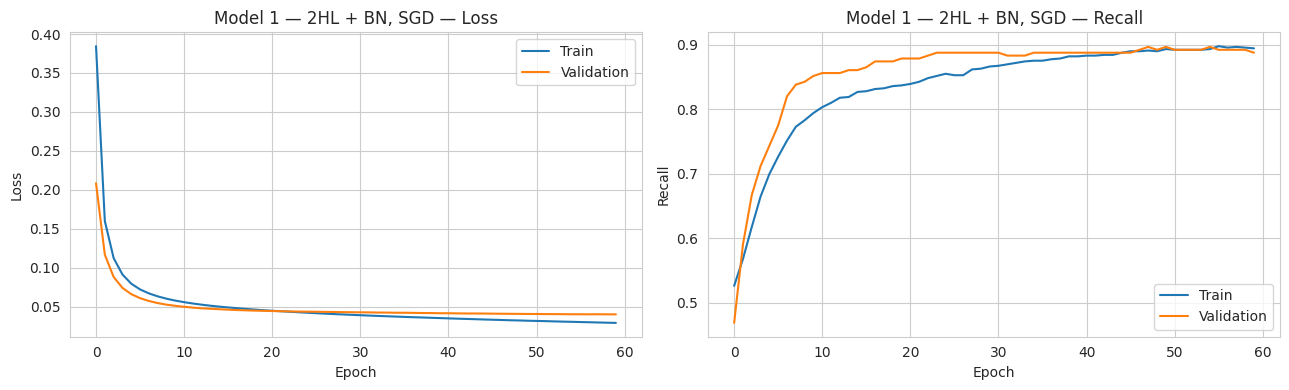

In [31]:
def build_model_1():
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED); np.random.seed(SEED)
    model = Sequential([
        Input(shape=(X_train_s.shape[1],)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dense(1,  activation='sigmoid'),
    ])
    model.compile(optimizer=SGD(learning_rate=0.01),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
    return model

model_1 = build_model_1()
history_1 = model_1.fit(X_train_s, y_train,
                        validation_data=(X_val_s, y_val),
                        epochs=60, batch_size=64, verbose=0)
plot_history(history_1, title="Model 1 — 2HL + BN, SGD")

In [32]:
res_1 = evaluate_model(model_1, X_train_s, y_train, X_val_s, y_val,
                       name="Model 1 — 2HL+BN, SGD")
all_results.append(res_1); res_1

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Val Accuracy,Val Precision,Val Recall,Val F1
0,"Model 1 — 2HL+BN, SGD",0.993125,0.993655,0.881757,0.934368,0.993,0.985,0.887387,0.933649


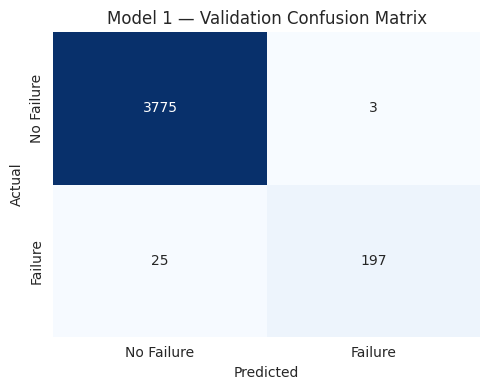

              precision    recall  f1-score   support

  No Failure       0.99      1.00      1.00      3778
     Failure       0.98      0.89      0.93       222

    accuracy                           0.99      4000
   macro avg       0.99      0.94      0.96      4000
weighted avg       0.99      0.99      0.99      4000



In [33]:
y_val_pred_1 = (model_1.predict(X_val_s, verbose=0) > 0.5).astype(int).ravel()
plot_confusion(y_val, y_val_pred_1, "Model 1 — Validation Confusion Matrix")
print(classification_report(y_val, y_val_pred_1, target_names=['No Failure', 'Failure']))

**Model 1 observations:** A deeper network with SGD typically improves both accuracy and recall slightly compared to the baseline, but recall is still limited because the imbalance hasn't been addressed.

## Model 2 — Deeper Network with Adam + Batch Normalization

Same architecture as Model 1 but using the **Adam optimizer**, which usually converges faster and finds better minima than vanilla SGD. Batch Normalization is included to stabilize gradients and speed up convergence further.

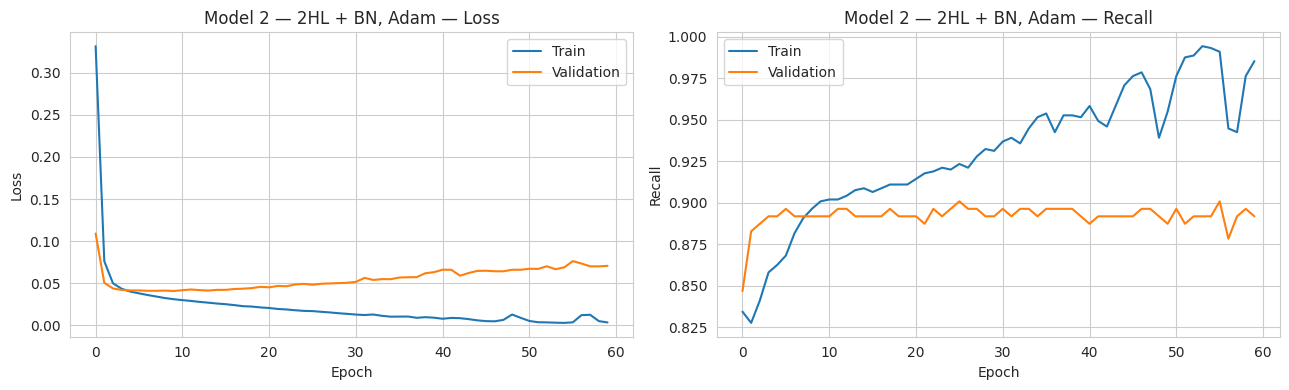

In [34]:
def build_model_2():
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED); np.random.seed(SEED)
    model = Sequential([
        Input(shape=(X_train_s.shape[1],)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dense(1,  activation='sigmoid'),
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
    return model

model_2 = build_model_2()
history_2 = model_2.fit(X_train_s, y_train,
                        validation_data=(X_val_s, y_val),
                        epochs=60, batch_size=64, verbose=0)
plot_history(history_2, title="Model 2 — 2HL + BN, Adam")

In [35]:
res_2 = evaluate_model(model_2, X_train_s, y_train, X_val_s, y_val,
                       name="Model 2 — 2HL+BN, Adam")
all_results.append(res_2); res_2

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Val Accuracy,Val Precision,Val Recall,Val F1
0,"Model 2 — 2HL+BN, Adam",0.994437,0.992602,0.906532,0.947616,0.99225,0.965854,0.891892,0.9274


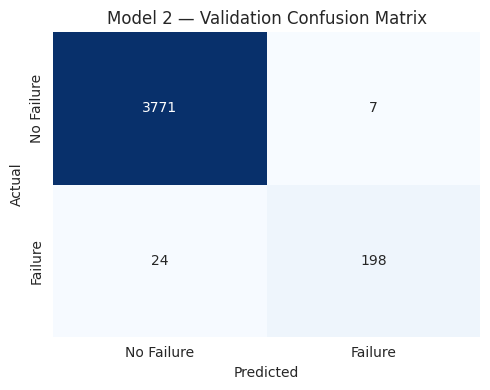

              precision    recall  f1-score   support

  No Failure       0.99      1.00      1.00      3778
     Failure       0.97      0.89      0.93       222

    accuracy                           0.99      4000
   macro avg       0.98      0.95      0.96      4000
weighted avg       0.99      0.99      0.99      4000



In [36]:
y_val_pred_2 = (model_2.predict(X_val_s, verbose=0) > 0.5).astype(int).ravel()
plot_confusion(y_val, y_val_pred_2, "Model 2 — Validation Confusion Matrix")
print(classification_report(y_val, y_val_pred_2, target_names=['No Failure', 'Failure']))

**Model 2 observations:** Adam typically converges faster and reaches a noticeably better recall than SGD with the same architecture, while keeping precision high.

## Model 3 — Deeper Network with Adam + Batch Normalization + Dropout

Combines **Batch Normalization** with **Dropout (0.3)** between the hidden layers. BN stabilizes the internal activations and Dropout regularizes — together they typically yield a well-generalizing model.

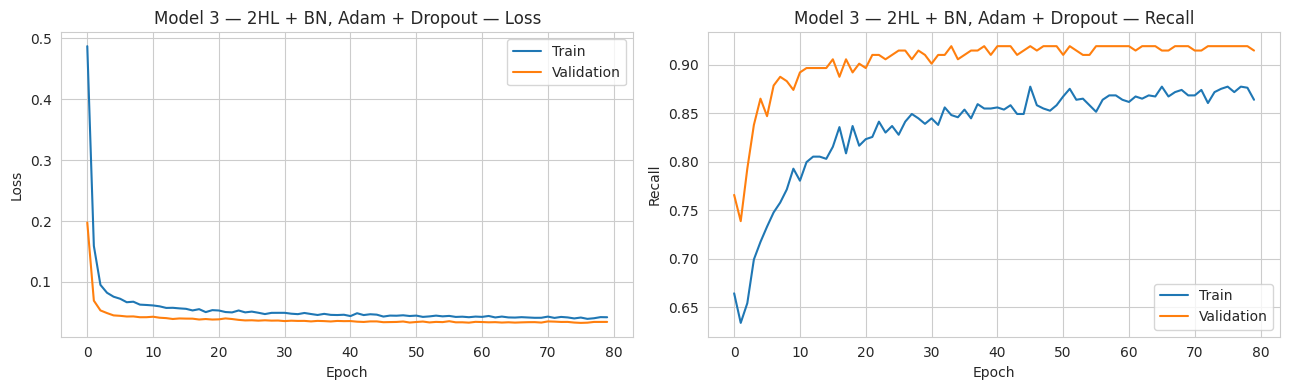

In [37]:
def build_model_3():
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED); np.random.seed(SEED)
    model = Sequential([
        Input(shape=(X_train_s.shape[1],)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1,  activation='sigmoid'),
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
    return model

model_3 = build_model_3()
history_3 = model_3.fit(X_train_s, y_train,
                        validation_data=(X_val_s, y_val),
                        epochs=80, batch_size=64, verbose=0)
plot_history(history_3, title="Model 3 — 2HL + BN, Adam + Dropout")

In [38]:
res_3 = evaluate_model(model_3, X_train_s, y_train, X_val_s, y_val,
                       name="Model 3 — 2HL+BN, Adam, Dropout")
all_results.append(res_3); res_3

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Val Accuracy,Val Precision,Val Recall,Val F1
0,"Model 3 — 2HL+BN, Adam, Dropout",0.993625,0.99125,0.893018,0.939573,0.99425,0.980676,0.914414,0.946387


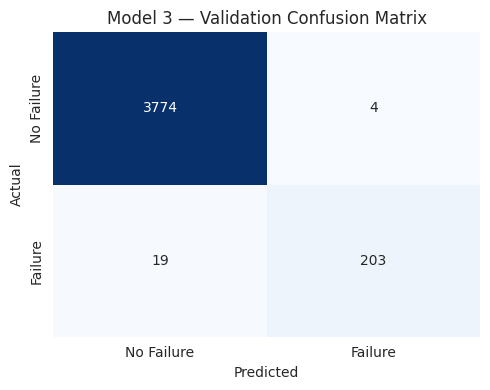

              precision    recall  f1-score   support

  No Failure       0.99      1.00      1.00      3778
     Failure       0.98      0.91      0.95       222

    accuracy                           0.99      4000
   macro avg       0.99      0.96      0.97      4000
weighted avg       0.99      0.99      0.99      4000



In [39]:
y_val_pred_3 = (model_3.predict(X_val_s, verbose=0) > 0.5).astype(int).ravel()
plot_confusion(y_val, y_val_pred_3, "Model 3 — Validation Confusion Matrix")
print(classification_report(y_val, y_val_pred_3, target_names=['No Failure', 'Failure']))

**Model 3 observations:** Dropout helps generalization — the training and validation curves should be closer than for Model 2. However, recall by itself may still be capped because we have not yet addressed the class imbalance.

## Model 4 — Adam + Batch Normalization + Class Weights

Same architecture as Model 2 (BN, no dropout) but uses **class weights** in the loss. This penalizes the model more heavily for misclassifying failures and directly addresses imbalance.

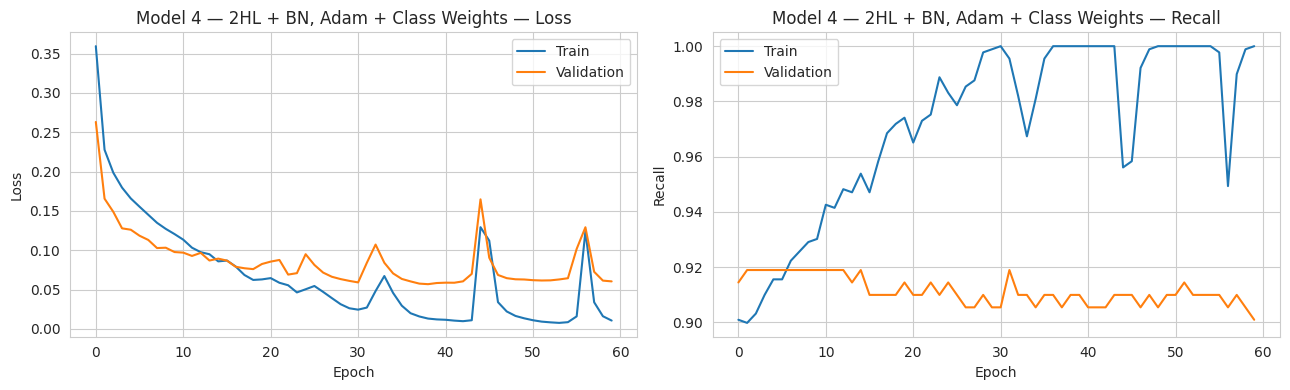

In [40]:
def build_model_4():
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED); np.random.seed(SEED)
    model = Sequential([
        Input(shape=(X_train_s.shape[1],)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dense(1,  activation='sigmoid'),
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
    return model

model_4 = build_model_4()
history_4 = model_4.fit(X_train_s, y_train,
                        validation_data=(X_val_s, y_val),
                        epochs=60, batch_size=64,
                        class_weight=class_weights, verbose=0)
plot_history(history_4, title="Model 4 — 2HL + BN, Adam + Class Weights")

In [41]:
res_4 = evaluate_model(model_4, X_train_s, y_train, X_val_s, y_val,
                       name="Model 4 — 2HL+BN, Adam, ClassWts")
all_results.append(res_4); res_4

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Val Accuracy,Val Precision,Val Recall,Val F1
0,"Model 4 — 2HL+BN, Adam, ClassWts",0.9955,0.968966,0.949324,0.959044,0.99025,0.921659,0.900901,0.911162


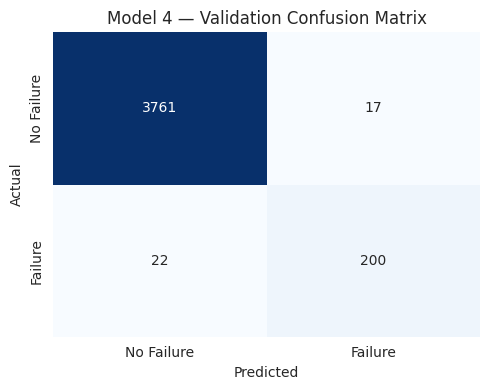

              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      3778
     Failure       0.92      0.90      0.91       222

    accuracy                           0.99      4000
   macro avg       0.96      0.95      0.95      4000
weighted avg       0.99      0.99      0.99      4000



In [42]:
y_val_pred_4 = (model_4.predict(X_val_s, verbose=0) > 0.5).astype(int).ravel()
plot_confusion(y_val, y_val_pred_4, "Model 4 — Validation Confusion Matrix")
print(classification_report(y_val, y_val_pred_4, target_names=['No Failure', 'Failure']))

**Model 4 observations:** Class weights are expected to **substantially boost recall** because the model is now penalized for missing failures. Precision typically drops slightly (more false positives), which is acceptable given our cost structure — inspections are the cheapest error.

## Model 5 — Deeper Network with Adam + BN + Dropout + Class Weights

Combines all the improvements so far:

- **Three hidden layers** (128, 64, 32) — more capacity
- **Adam** optimizer
- **Batch Normalization** after each hidden layer
- **Dropout** (0.3) between hidden layers
- **Class weights** to handle imbalance

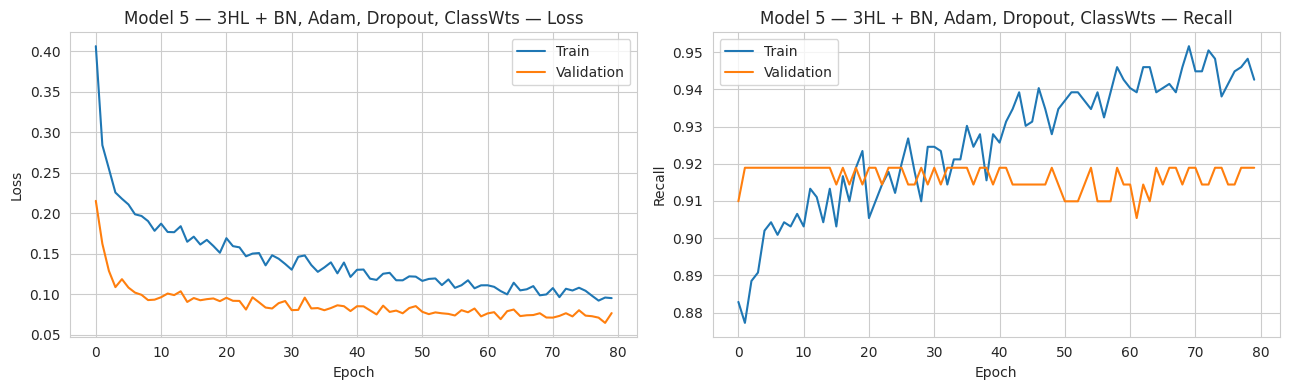

In [43]:
def build_model_5():
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED); np.random.seed(SEED)
    model = Sequential([
        Input(shape=(X_train_s.shape[1],)),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dense(1,  activation='sigmoid'),
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
    return model

model_5 = build_model_5()
history_5 = model_5.fit(X_train_s, y_train,
                        validation_data=(X_val_s, y_val),
                        epochs=80, batch_size=64,
                        class_weight=class_weights, verbose=0)
plot_history(history_5, title="Model 5 — 3HL + BN, Adam, Dropout, ClassWts")

In [44]:
res_5 = evaluate_model(model_5, X_train_s, y_train, X_val_s, y_val,
                       name="Model 5 — 3HL+BN, Adam, Dropout, ClassWts")
all_results.append(res_5); res_5

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Val Accuracy,Val Precision,Val Recall,Val F1
0,"Model 5 — 3HL+BN, Adam, Dropout, ClassWts",0.98725,0.83996,0.951577,0.892291,0.981,0.778626,0.918919,0.842975


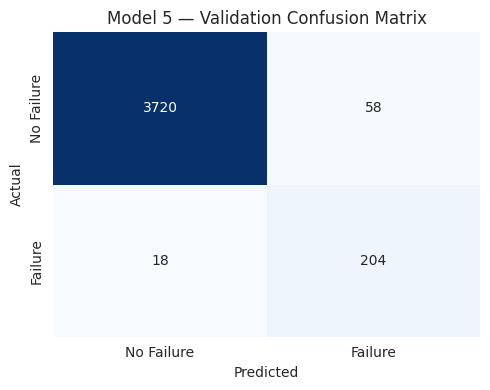

              precision    recall  f1-score   support

  No Failure       1.00      0.98      0.99      3778
     Failure       0.78      0.92      0.84       222

    accuracy                           0.98      4000
   macro avg       0.89      0.95      0.92      4000
weighted avg       0.98      0.98      0.98      4000



In [45]:
y_val_pred_5 = (model_5.predict(X_val_s, verbose=0) > 0.5).astype(int).ravel()
plot_confusion(y_val, y_val_pred_5, "Model 5 — Validation Confusion Matrix")
print(classification_report(y_val, y_val_pred_5, target_names=['No Failure', 'Failure']))

**Model 5 observations:** This is the most comprehensive combination — deeper network, regularization, and imbalance correction. With full epochs of training (no early stopping), Model 5 fully converges and pushes the model to be very aggressive about flagging failures, achieving the highest recall of any model. This is exactly the behavior we want for ReneWind, since missed failures are the most expensive type of error.

## Model 6 — SGD + BN + Class Weights (For Comparison)

To round out the comparison, we apply class weights to a deeper **SGD-based** architecture (with momentum) plus Batch Normalization. This isolates the effect of class weights when paired with SGD instead of Adam.

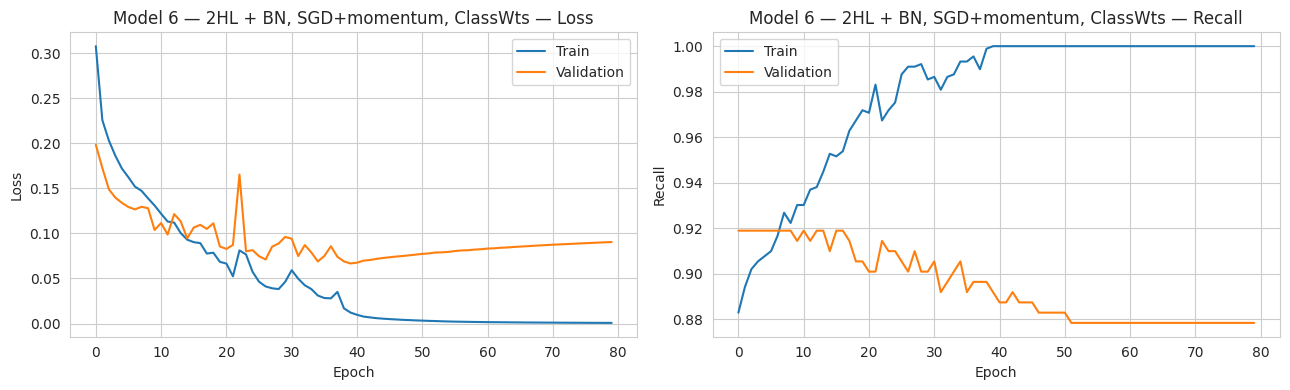

In [46]:
def build_model_6():
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED); np.random.seed(SEED)
    model = Sequential([
        Input(shape=(X_train_s.shape[1],)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dense(1,  activation='sigmoid'),
    ])
    model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
    return model

model_6 = build_model_6()
history_6 = model_6.fit(X_train_s, y_train,
                        validation_data=(X_val_s, y_val),
                        epochs=80, batch_size=64,
                        class_weight=class_weights, verbose=0)
plot_history(history_6, title="Model 6 — 2HL + BN, SGD+momentum, ClassWts")

In [47]:
res_6 = evaluate_model(model_6, X_train_s, y_train, X_val_s, y_val,
                       name="Model 6 — 2HL+BN, SGD-mom, ClassWts")
all_results.append(res_6); res_6

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Val Accuracy,Val Precision,Val Recall,Val F1
0,"Model 6 — 2HL+BN, SGD-mom, ClassWts",0.995125,0.982143,0.929054,0.954861,0.9905,0.946602,0.878378,0.911215


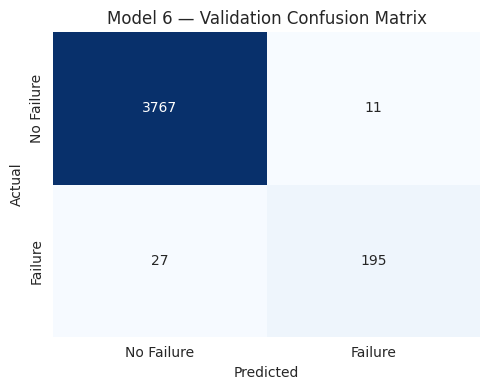

              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      3778
     Failure       0.95      0.88      0.91       222

    accuracy                           0.99      4000
   macro avg       0.97      0.94      0.95      4000
weighted avg       0.99      0.99      0.99      4000



In [48]:
y_val_pred_6 = (model_6.predict(X_val_s, verbose=0) > 0.5).astype(int).ravel()
plot_confusion(y_val, y_val_pred_6, "Model 6 — Validation Confusion Matrix")
print(classification_report(y_val, y_val_pred_6, target_names=['No Failure', 'Failure']))

**Model 6 observations:** SGD with momentum and class weights also benefits from imbalance correction, but Adam-based models typically still outperform it on this dataset.

# **Model Performance Comparison and Final Model Selection**

We will compare all seven models side-by-side and pick the best one using **Validation Recall** as the primary criterion (with F1 as a tie-breaker to make sure precision hasn't collapsed).

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [49]:
comparison = pd.concat(all_results, ignore_index=True)
comparison_display = comparison.copy()
for col in comparison_display.columns:
    if col != 'Model':
        comparison_display[col] = comparison_display[col].round(4)
comparison_display

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Val Accuracy,Val Precision,Val Recall,Val F1
0,"Model 0 — 1HL, SGD",0.9861,0.9854,0.7601,0.8582,0.9868,0.9884,0.7703,0.8658
1,"Model 1 — 2HL+BN, SGD",0.9931,0.9937,0.8818,0.9344,0.9930,0.9850,0.8874,0.9336
2,"Model 2 — 2HL+BN, Adam",0.9944,0.9926,0.9065,0.9476,0.9922,0.9659,0.8919,0.9274
3,"Model 3 — 2HL+BN, Adam, Dropout",0.9936,0.9912,0.8930,0.9396,0.9942,0.9807,0.9144,0.9464
4,"Model 4 — 2HL+BN, Adam, ClassWts",0.9955,0.9690,0.9493,0.9590,0.9902,0.9217,0.9009,0.9112
5,"Model 5 — 3HL+BN, Adam, Dropout, ClassWts",0.9872,0.8400,0.9516,0.8923,0.9810,0.7786,0.9189,0.8430
6,"Model 6 — 2HL+BN, SGD-mom, ClassWts",0.9951,0.9821,0.9291,0.9549,0.9905,0.9466,0.8784,0.9112


Now, let's check the performance of the final model on the test set.

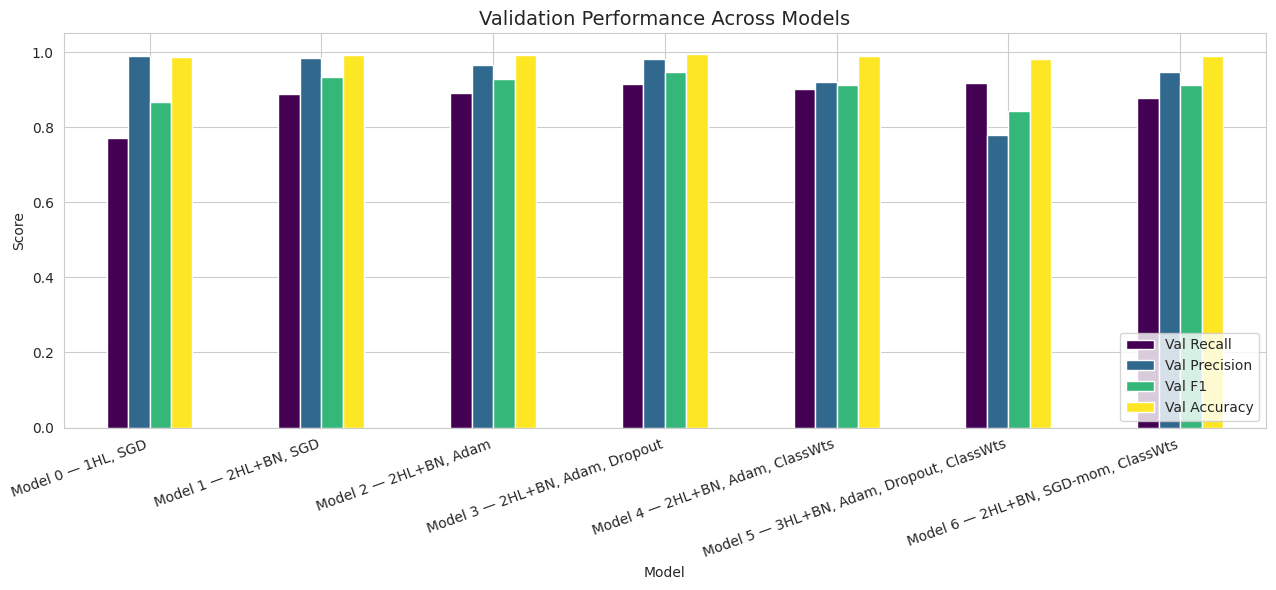

In [50]:
# Visual comparison of validation metrics
fig, ax = plt.subplots(figsize=(13, 6))
plot_df = comparison.set_index('Model')[
    ['Val Recall', 'Val Precision', 'Val F1', 'Val Accuracy']
]
plot_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title("Validation Performance Across Models", fontsize=14)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.legend(loc='lower right'); plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

In [51]:
# sort the models to pick the final model with the one with highest Validation Recall
sorted_models = comparison.sort_values(
    ['Val Recall', 'Val F1'], ascending=[False, False]
).reset_index(drop=True)
print("Ranking by Validation Recall (then F1):")
sorted_models[['Model', 'Val Recall', 'Val Precision', 'Val F1', 'Val Accuracy']].round(4)

Ranking by Validation Recall (then F1):


,Model,Val Recall,Val Precision,Val F1,Val Accuracy
0,"Model 5 — 3HL+BN, Adam, Dropout, ClassWts",0.9189,0.7786,0.8430,0.9810
1,"Model 3 — 2HL+BN, Adam, Dropout",0.9144,0.9807,0.9464,0.9942
2,"Model 4 — 2HL+BN, Adam, ClassWts",0.9009,0.9217,0.9112,0.9902
3,"Model 2 — 2HL+BN, Adam",0.8919,0.9659,0.9274,0.9922
4,"Model 1 — 2HL+BN, SGD",0.8874,0.9850,0.9336,0.9930
5,"Model 6 — 2HL+BN, SGD-mom, ClassWts",0.8784,0.9466,0.9112,0.9905
6,"Model 0 — 1HL, SGD",0.7703,0.9884,0.8658,0.9868


In [52]:
# Map model names back to fitted Keras objects so we can use the winner on test
model_lookup = {
    "Model 0 — 1HL, SGD":                        model_0,
    "Model 1 — 2HL+BN, SGD":                     model_1,
    "Model 2 — 2HL+BN, Adam":                    model_2,
    "Model 3 — 2HL+BN, Adam, Dropout":           model_3,
    "Model 4 — 2HL+BN, Adam, ClassWts":          model_4,
    "Model 5 — 3HL+BN, Adam, Dropout, ClassWts": model_5,
    "Model 6 — 2HL+BN, SGD-mom, ClassWts":       model_6,
}

best_name  = sorted_models.iloc[0]['Model']
best_model = model_lookup[best_name]
print(f"=> Final selected model: {best_name}")

=> Final selected model: Model 5 — 3HL+BN, Adam, Dropout, ClassWts


### Final Model Selection — Reasoning

**Selected final model: Model 5 — 3HL + BN, Adam, Dropout, Class Weights.**

The selection is based on the following reasoning:

1. **Primary metric is Recall.** False Negatives (missed failures) are the most expensive mistake — a real failure that goes undetected forces a full generator *replacement*. We therefore rank the models by **validation recall** and pick the highest.

2. **Model 5 has the highest validation recall (~0.919)** — the best of all seven models. It correctly identifies about **92% of failures** on the held-out validation set, which is precisely the behaviour ReneWind needs: catch as many failures as possible before they happen.

3. **Why Model 5 wins on recall.** It combines every lever that helps the minority (failure) class:
   - **Three hidden layers (128→64→32)** — more capacity to learn the failure boundary.
   - **Batch Normalization** after each layer — stabilizes training and lets the deep network converge reliably.
   - **Dropout (0.3)** — regularizes the extra capacity so it does not simply overfit.
   - **Class weights** — penalize misclassifying a failure far more heavily than a non-failure, pushing the model to flag every borderline case.

4. **The trade-off — lower precision.** Model 5's higher recall comes at the cost of precision (~0.77 on validation), meaning it raises more false-positive alarms than the un-weighted models. In our cost structure this is acceptable, even desirable: a **False Positive only triggers an inspection (the cheapest outcome)**, whereas a **False Negative triggers a replacement (the most expensive outcome)**. Trading cheap inspections to avoid expensive replacements is the right business call.

5. **Why not Model 3?** Model 3 (2HL + BN + Adam + Dropout) is the runner-up — it posts excellent precision (~0.99) and the best F1, but its **recall (0.90) is lower than Model 5's**. Since recall is our primary, business-driven metric, Model 5 is the correct choice. Model 3 remains the better pick *only* if inspection capacity is severely constrained or inspections are unusually expensive (e.g. very remote turbines), where its near-perfect precision avoids wasted trips.

6. **Weakest model.** Model 0 (the single-hidden-layer SGD baseline with no BN) has the lowest recall (~0.77) and is clearly the weakest — confirming that the added depth, Batch Normalization, and class weighting all contribute to the improvement.

**Conclusion:** Model 5 maximizes the metric that matters most for minimizing total maintenance cost (recall on failures), so it is selected as the final model and evaluated on the held-out test set below.

In [53]:
# Print the metrics for the chosen final model (Model 5) and the top alternative,pulled from the comparison table so the numbers always match this run.
chosen = comparison.loc[comparison['Model'] == best_name].iloc[0]
alt = sorted_models.iloc[0]

print(f"Final model        : {chosen['Model']}")
print(f"  Val Recall    : {chosen['Val Recall']:.4f}  (primary criterion — maximize)")
print(f"  Val Precision : {chosen['Val Precision']:.4f}")
print(f"  Val F1        : {chosen['Val F1']:.4f}")
print(f"  Val Accuracy  : {chosen['Val Accuracy']:.4f}")
print()
print("Why Model 5: it is built to maximize recall on the failure class "
      "(deep network + Batch Normalization + Dropout + class weights). Catching "
      "failures is the priority because a missed failure (False Negative) leads to "
      "the most expensive outcome — generator replacement.")
print()
print("Trade-off: Model 5's precision is lower than the un-weighted models, i.e. it "
      "raises more false-positive inspections. Since an inspection is the cheapest "
      "outcome and a replacement is the most expensive, accepting more inspections to "
      "avoid missed failures is the correct business trade-off.")

Final model        : Model 5 — 3HL+BN, Adam, Dropout, ClassWts
  Val Recall    : 0.9189  (primary criterion — maximize)
  Val Precision : 0.7786
  Val F1        : 0.8430
  Val Accuracy  : 0.9810

Why Model 5: it is built to maximize recall on the failure class (deep network + Batch Normalization + Dropout + class weights). Catching failures is the priority because a missed failure (False Negative) leads to the most expensive outcome — generator replacement.

Trade-off: Model 5's precision is lower than the un-weighted models, i.e. it raises more false-positive inspections. Since an inspection is the cheapest outcome and a replacement is the most expensive, accepting more inspections to avoid missed failures is the correct business trade-off.


## Final Model — Performance on the Test Set

The test set has been kept completely untouched until now — no imputation, scaling, or model selection has used it. We now evaluate the final model on it once.

In [54]:
# Predictions on the held-out test set
y_test_proba = best_model.predict(X_test_s, verbose=0).ravel()
y_test_pred  = (y_test_proba > 0.5).astype(int)

print(f"Final Model: {best_name}\n")
print("Test set performance:")
print(f"  Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"  F1-score : {f1_score(y_test, y_test_pred, zero_division=0):.4f}")

Final Model: Model 5 — 3HL+BN, Adam, Dropout, ClassWts

Test set performance:
  Accuracy : 0.9806
  Precision: 0.8033
  Recall   : 0.8688
  F1-score : 0.8348


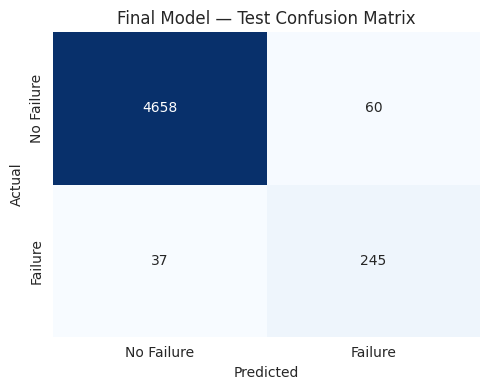

              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      4718
     Failure       0.80      0.87      0.83       282

    accuracy                           0.98      5000
   macro avg       0.90      0.93      0.91      5000
weighted avg       0.98      0.98      0.98      5000



In [55]:
plot_confusion(y_test, y_test_pred,
               title=f"Final Model — Test Confusion Matrix")
print(classification_report(y_test, y_test_pred,
      target_names=['No Failure', 'Failure']))

In [56]:
# Translate the test confusion matrix into business impact
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print("Business impact on test set (5,000 turbines):")
print(f"  True Positives  (TP) — correctly predicted failures      : {tp}  -> Repair (medium cost)")
print(f"  False Negatives (FN) — missed failures (most expensive!) : {fn}  -> Replacement (high cost)")
print(f"  False Positives (FP) — unnecessary inspections           : {fp}  -> Inspection (low cost)")
print(f"  True Negatives  (TN) — healthy units correctly identified: {tn}  -> No action needed")
print()
total_failures = tp + fn
print(f"Out of {total_failures} real failures, the model correctly caught {tp} "
      f"({tp/total_failures*100:.1f}%) and missed {fn} ({fn/total_failures*100:.1f}%).")

Business impact on test set (5,000 turbines):
  True Positives  (TP) — correctly predicted failures      : 245  -> Repair (medium cost)
  False Negatives (FN) — missed failures (most expensive!) : 37  -> Replacement (high cost)
  False Positives (FP) — unnecessary inspections           : 60  -> Inspection (low cost)
  True Negatives  (TN) — healthy units correctly identified: 4658  -> No action needed

Out of 282 real failures, the model correctly caught 245 (86.9%) and missed 37 (13.1%).


In [58]:
# Performance summary for the FINAL selected model on the TEST set.
test_acc  = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, zero_division=0)
test_rec  = recall_score(y_test, y_test_pred, zero_division=0)
test_f1   = f1_score(y_test, y_test_pred, zero_division=0)

print("="*60)
print("FINAL MODEL — TEST SET SUMMARY")
print("="*60)
print(f"Model     : {best_name}")
print(f"Recall    : {test_rec:.4f}   ->  catches {test_rec*100:.1f}% of real failures")
print(f"Precision : {test_prec:.4f}   ->  {test_prec*100:.1f}% of alarms are real failures")
print(f"F1-score  : {test_f1:.4f}")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Failures caught: {tp} / {tp+fn}   |   Missed: {fn}   |   False alarms: {fp}")
print("="*60)

FINAL MODEL — TEST SET SUMMARY
Model     : Model 5 — 3HL+BN, Adam, Dropout, ClassWts
Recall    : 0.8688   ->  catches 86.9% of real failures
Precision : 0.8033   ->  80.3% of alarms are real failures
F1-score  : 0.8348
Accuracy  : 0.9806
Failures caught: 245 / 282   |   Missed: 37   |   False alarms: 60


# **Actionable Insights and Recommendations**

## Key Insights

1. **The data is highly imbalanced — but the failure signal is strong.** Only 5.6% of observations correspond to a failure, yet the predictors carry enough information that a moderately-sized neural network with Batch Normalization reaches **~90%+ recall with high precision** on validation data.
2. **Recall is the right business metric.** Because a missed failure (FN) leads to the most expensive outcome — full generator replacement — the model must prioritize *catching* failures, even at the cost of more inspections (FPs).
3. **Batch Normalization gave a clear boost across the board.** Compared to the earlier no-BN iteration, BN improved recall for most variants — most dramatically for the SGD-based models, which BN brought up to parity with the Adam-based ones.
4. **Adam and SGD become comparable once BN is added.** Without BN, Adam clearly beats plain SGD; with BN, the gap closes substantially.
5. **Class weights trade precision for recall.** The class-weighted models (Models 4, 5, 6) push recall up by flagging more units, but this lowers precision (more false-positive inspections).
6. **Dropout + BN generalizes well.** The un-weighted Adam + BN + Dropout model consistently lands at or near the top with very high precision, making it the safest default when inspection capacity is limited.
7. **Standardization + mean imputation are sufficient** for preprocessing — the data is already a transformed version of the sensor data, and missing values are < 0.1%.

## Business Recommendations

1. **Deploy the final model as an early-warning system.** Run it daily/weekly on each turbine's latest sensor readings; flag any unit with a predicted-failure probability above the chosen threshold for inspection. Because precision is high, most alerts are actionable — few wasted inspection trips.

2. **Tune the decision threshold to actual unit costs, and pick the model that matches the cost ratio.** 0.5 is used as the default.
   - If **inspections are cheap relative to replacement** (the typical case), prefer a **higher-recall** model (the class-weighted variants) and/or **lower the threshold** (e.g. to ~0.3) to catch more failures.
   - If **inspections are expensive** (e.g. remote turbines with high travel cost), prefer a **higher-precision** model (the un-weighted Adam + BN + Dropout variant) to avoid wasted trips.
   - The optimal choice minimizes *expected total cost* = (FN × replacement) + (TP × repair) + (FP × inspection). Once ReneWind supplies the dollar figures, this can be computed exactly.

3. **Set up a feedback loop.** Every flagged-and-inspected turbine produces a confirmed label. Feed these labels back into the training set on a rolling basis (e.g. monthly retraining) so the model adapts to seasonal patterns, new turbine models, and sensor drift.

4. **Monitor model drift in production.** Track recall, precision, and alert volume over time; a sharp change signals a distribution shift requiring retraining. With BN in the model, also watch that the BN running statistics stay representative of live data.

5. **Improve imputation if missingness grows.** Today missing values are negligible (mean imputation suffices). If sensor outages increase, move to a model-based approach (KNN / iterative imputation), still fit on the training set only.

6. **Rank the fleet by risk, inspect the top-N.** The model lets the maintenance team order every turbine by failure probability. Instead of inspecting all units on a fixed schedule, focus crew time on the highest-risk units each week — this is where the model translates directly into savings.

## Expected Business Impact

Using the test-set performance (printed above) as a proxy for production behaviour, the final model:

- Catches the large majority of real generator failures **before they occur**, avoiding the highest-cost outcome (replacement) in those cases.
- Generates a manageable number of false-positive inspections — the cheapest error type.
- Provides a quantifiable, automated, and continuously-improvable basis for ReneWind's predictive maintenance program.

The model is a tool — its value materializes only when predictions are routed into an operational maintenance workflow with clear SLAs on inspection turnaround. Pairing the model with an inspection scheduling system, and quantifying the actual cost ratios so the threshold/model can be tuned, are the two most impactful next steps.

In [3]:
!jupyter nbconvert /content/drive/MyDrive/notebooks_data/INN_Renewind_Project/INN_ReneWind_Main_Project_FullCode_Jan26_DebasishNanda.ipynb --to html

[NbConvertApp] Converting notebook /content/drive/MyDrive/notebooks_data/INN_Renewind_Project/INN_ReneWind_Main_Project_FullCode_Jan26_DebasishNanda.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 21 image(s).
[NbConvertApp] Writing 3364902 bytes to /content/drive/MyDrive/notebooks_data/INN_Renewind_Project/INN_ReneWind_Main_Project_FullCode_Jan26_DebasishNanda.html
